In [4]:
# Exercice 6 — Analyse TMDB — notes et popularité 

import pandas as pd 

films = pd.read_csv('../datasets/tmdb_clean.csv') 
 
# Top 10 films les mieux notés 
top10 = films.nlargest(10, 'vote_average')[['title', 'vote_average', 'vote_count']] 
print('Top 10 films les mieux notés :') 
print(top10)
print("\n")

# Nombre de films par année 
films_par_annee = films.groupby('annee')['title'].count().reset_index() 
films_par_annee.columns = ['année', 'nb_films'] 
print("films par an :")
print(films_par_annee)

Top 10 films les mieux notés :
                                      title  vote_average  vote_count
0                          Cuando Sea Joven           8.8         202
1                             The Godfather           8.7       17484
2                  The Shawshank Redemption           8.7       23302
3  The Boy, the Mole, the Fox and the Horse           8.7         222
4                     The Godfather Part II           8.6       10589
5                          Schindler's List           8.6       13770
6               Dilwale Dulhania Le Jayenge           8.6        4061
7                             Spirited Away           8.5       13961
8                              12 Angry Men           8.5        7052
9                                Your Name.           8.5        9515


films par an :
     année  nb_films
0     1895         1
1     1902         1
2     1903         1
3     1911         1
4     1915         1
..     ...       ...
107   2019       403
108   2020    

In [ ]:
## Exercice 6 — Analyse TMDB : notes et popularité

#Ce que j'ai fait :**
"""Identifié les 10 films les mieux notés avec nlargest() sur
vote_average, et calculé le nombre de films produits par année
avec groupby() sur la colonne annee."""

#*Pourquoi je l'ai fait :**
"""Sur 8820 films, nlargest() isole immédiatement les extrêmes
sans parcourir l'ensemble du dataset. Le groupby sur l'année
permet de voir la répartition de la production cinématographique
dans le temps — une dimension absente des autres analyses."""

#Ce que ça m'a appris :**
"""Deux constats distincts.

Sur le top 10 : nlargest() sur vote_average seul est insuffisant.
Cuando Sea Joven est premier avec 8.8 mais seulement 202 votes.
The Shawshank Redemption a la même note de 8.7 avec 23 302 votes
— statistiquement beaucoup plus représentatif. Une note élevée
avec peu de votes est un biais à identifier avant toute
conclusion.

Sur les films par année : le dataset couvre 112 ans de cinéma,
de 1895 à 2023. La production est très concentrée sur la période
récente — 2019 est l'année la plus représentée avec 403 films.
2023 n'a que 7 films, ce qui suggère que le dataset a été
constitué en début d'année 2023."""

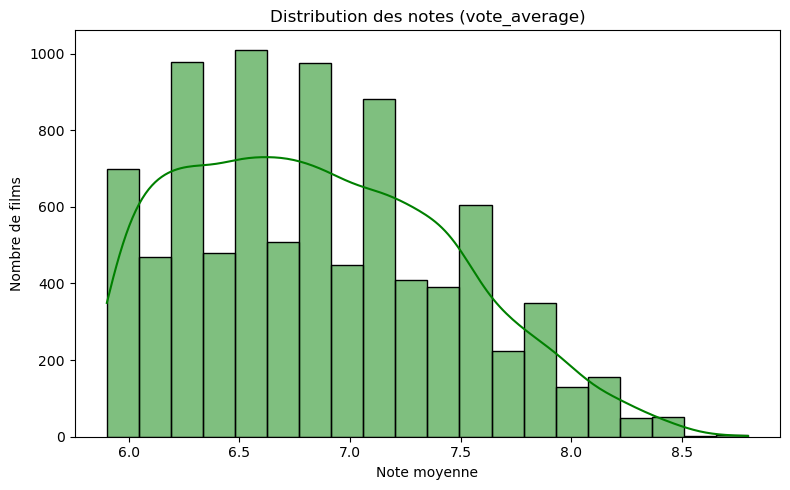

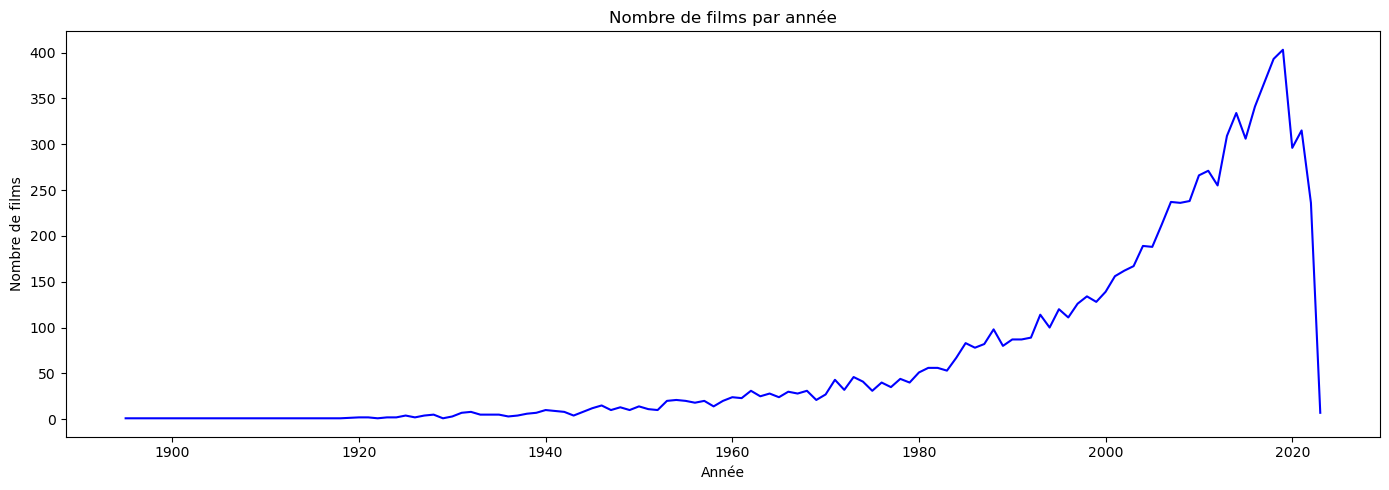

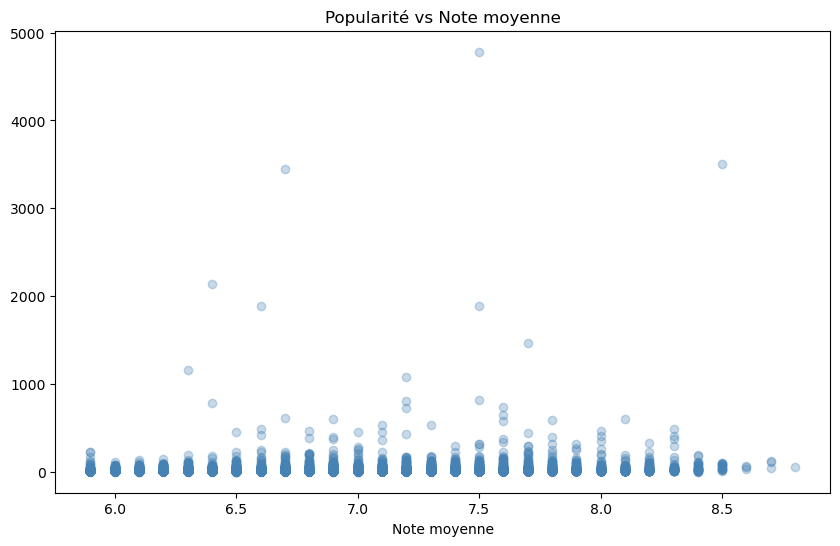

In [11]:

import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
 
films = pd.read_csv('../datasets/tmdb_clean.csv') 


# Distribution des notes 
plt.figure(figsize=(8, 5)) 
sns.histplot(films['vote_average'], bins=20, color='green', kde=True) 
plt.title('Distribution des notes (vote_average)') 
plt.xlabel('Note moyenne') 
plt.ylabel('Nombre de films') 
plt.tight_layout() 
plt.savefig('../visuals/distribution_notes.png') 
plt.show() 

# Nombre de films par année 
films_par_annee = films.groupby('annee')['title'].count().reset_index() 
films_par_annee.columns = ['annee', 'nb_films'] 

plt.figure(figsize=(14, 5)) 
plt.plot(films_par_annee['annee'], films_par_annee['nb_films'], color='blue') 
plt.title('Nombre de films par année') 
plt.xlabel('Année') 
plt.ylabel('Nombre de films') 
plt.tight_layout() 
plt.savefig('../visuals/films_par_annee.png') 
plt.show() 
 
# Popularite vs note — scatter plot 
plt.figure(figsize=(10, 6)) 
plt.scatter(films['vote_average'], films['popularity'], alpha=0.3, color='steelblue') 
plt.title('Popularité vs Note moyenne') 
plt.xlabel('Note moyenne') 
plt.savefig('../visuals/popularité_vs_moyenne.png') 
plt.show() 
 

In [ ]:
#Graphique 1 — Distribution des notes (Histogramme)
"""
L'axe X c'est la note moyenne, l'axe Y c'est le nombre de films à cette note.
La distribution est asymétrique vers la gauche. 
la courbe KDE monte progressivement jusqu'à un pic autour de 6.5, 
puis descend plus doucement vers les notes élevées.

Les constats :
La majorité des films se concentrent entre 6.0 et 7.5 — c'est le ventre du dataset
Le pic est autour de 6.5 avec environ 1000 films
Les notes au-dessus de 8.0 sont rares — moins de 200 films
Très peu de films en dessous de 6.0 — le dataset semble filtré,
les films très mal notés sont absents ou peu représentés

Ce résultat confirme le CV de 9% observé en semaine 1 
les notes sont effectivement très resserrées entre 6.0 et 8.5. """

#Graphique 2 — Nombre de films par année (Line chart)
"""
La courbe raconte l'histoire du cinéma mondial en un seul graphique.
Les constats :

De 1895 à 1950 : production quasi nulle, quelques films par an
De 1950 à 1990 : croissance lente et régulière
De 1990 à 2019 : explosion de la production, la courbe monte fortement
2019 est le pic absolu à 403 films
La chute brutale après 2019 s'explique par deux facteurs :
l'arrêt des productions pendant le Covid en 2020, et le fait que 2023 n'a que 7 films 
le dataset était incomplet au moment de sa constitution"""


#Graphique 3 — Popularité vs Note moyenne (Scatter plot)
"""
Chaque point est un film. L'axe X est sa note, l'axe Y est sa popularité.
Les constats :

La grande masse des points est collée en bas 
popularité proche de zéro pour la grande majorité des films, quelle que soit leur note
Quelques points isolés très hauts 
des films extrêmement populaires dispersés sur toute la plage de notes
Le point le plus haut à environ 4800 de popularité se trouve autour de 7.5 — un film très populaire avec une bonne note
Il n'y a pas de tendance linéaire visible — les films les mieux notés ne sont pas nécessairement les plus populaires

Le constat global : popularité et note sont deux métriques indépendantes. 
Un film peut être très populaire avec une note moyenne, et un film très bien noté peut rester confidentiel."""

In [ ]:
## Exercice 6 — Visualisations TMDB: distribution et relations

#*Ce que j'ai fait :**
"""Visualisé la distribution des notes avec un histogramme,
L'évolution de la production cinématographique par année
avec un line chart, et la relation entre popularité et note
avec un scatter plot."""

#**Pourquoi je l'ai fait :**
"""Ces trois graphiques répondent à trois questions différentes
sur le même dataset. L'histogramme montre comment les notes
se répartissent. Le line chart montre une tendance dans le
temps. Le scatter plot teste visuellement s'il existe une
relation entre deux variables numériques."""

#**Ce que ça m'a appris :**
"""
Trois constats distincts.

Distribution des notes : la majorité des films se concentrent
entre 6.0 et 7.5 — le dataset ne contient presque pas de
films très mal notés. Les notes au-dessus de 8.0 sont rares.

Production par année : la courbe explose à partir des années
1990 avec un pic en 2019 à 403 films. La chute après 2019
reflète l'impact du Covid et l'incomplétude du dataset en 2023.

Popularité vs note : aucune tendance linéaire visible. La
grande majorité des films ont une popularité proche de zéro
quelle que soit leur note. Popularité et qualité perçue sont
deux métriques indépendantes sur ce dataset."""